In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, Bounds
import polyplotter as pp
from functools import partial

In [87]:
def plot_resonance(freq_array, data_array, name_array):

    fig1, ax1 = plt.subplots(1)
    fig2, ax2 = plt.subplots(1)
    fig3, ax3 = plt.subplots(1)

    for i in range(len(data_array)):
        
        ax1.plot(freq_array[i]/1e9,20*np.log10(np.abs(data_array[i])),'.',label=name_array[i])
        ax1.set_xlabel('Frequency (GHz)')
        ax1.set_ylabel('|S21| (dB)')

        ax2.plot(freq_array[i]/1e9,np.unwrap(np.angle(data_array[i]))*180/np.pi,'.',label=name_array[i])
        ax2.set_xlabel('Frequency (GHz)')
        ax2.set_ylabel('Phase (deg)')

        ax3.plot(np.real(data_array[i]), np.imag(data_array[i]),'.',label=name_array[i])
        ax3.set_xlabel('Re(S21)')
        ax3.set_ylabel('Im(S21)')
       
    ax1.legend()
    ax2.legend()
    ax3.legend()
    fig3.gca().set_aspect('equal')
    
def residuals(f, *args, func=None, data=None):
    return np.abs(data-func(f, *args))**2

def resonator_fit(freqs, data, func, p0, plot=True):
    bounding = Bounds(lb=[0,0,0,-np.inf,-np.inf,-np.inf], ub=[np.inf,12000,np.inf,np.inf,np.inf,np.inf])
    popt, pcov = curve_fit(partial(residuals, data=data, func=func), freqs, 0*freqs, p0=p0, maxfev = 100000, bounds = bounding)
    if plot:
        plot_data_fit(freqs, data, func, popt)
    return popt

def plot_data_fit(x, data, fitf, popt):
    plt.figure()
    smooth_x = np.linspace(x[0], x[-1], 10000)
    fit = fitf(smooth_x, *popt)
    fit_pts = fitf(x, *popt)
    f1 = plt.figure()
    ax1 = f1.subplots()
    f2 = plt.figure()
    ax2 = f2.subplots()
    f3 = plt.figure()
    ax3 = f3.subplots()
    axs = (ax1, ax2, ax3)
    plot_complex(x, data, fmt='k.', axs=axs)
    plot_complex(smooth_x, fit, fmt='r--', axs=axs)
    
def plot_complex(x, data, fmt='k.', axs=None):
    if axs is None:
        f1 = plt.figure()
        ax1 = f1.subplots()
        f2 = plt.figure()
        ax2 = f2.subplots()
        f3 = plt.figure()
        ax3 = f3.subplots()
    else:
        ax1, ax2, ax3 = axs
    ax1.plot(x, np.abs(data), fmt)
    ax2.plot(x, np.unwrap(np.angle(data)), fmt)
    ax3.plot(np.real(data), np.imag(data), fmt)

In [110]:
path = '/home/user/Documents/axion_rnd/misc_instrument_outputs/comissioning/antenna_testing/sweeps/'

data = pd.read_csv(path+'l_153.74_c_30_z_17.4.txt',sep=',')
data_freq = data['freq (Hz)'].to_numpy(dtype = float)
data_resp = data['resp'].to_numpy(dtype=complex)

background = pd.read_csv(path+'l_153.74_c_10_background.txt',sep=',')
background_freq = background['freq (Hz)'].to_numpy(dtype = float)
background_resp = background['resp'].to_numpy(dtype=complex)


In [111]:
data_no_background_resp = data_resp/background_resp

data_mag = np.abs(data_no_background_resp)
data_phase = np.angle(data_no_background_resp)

data_freq_400 = np.append(data_freq[0:200], data_freq[len(data_freq)-200:len(data_freq)])
data_mag_400 = np.append(data_mag[0:200], data_mag[len(data_mag)-200:len(data_mag)])
data_phase_400 = np.append(data_phase[0:200], data_phase[len(data_phase)-200:len(data_phase)])

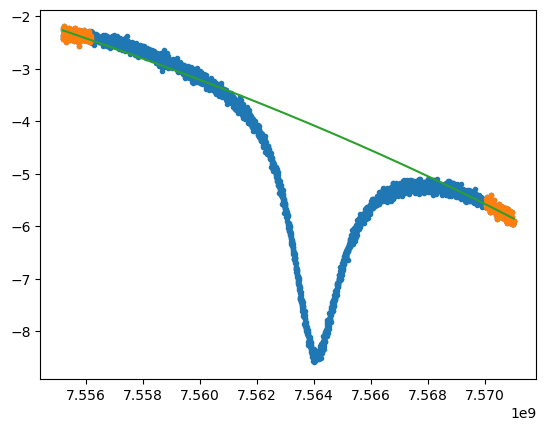

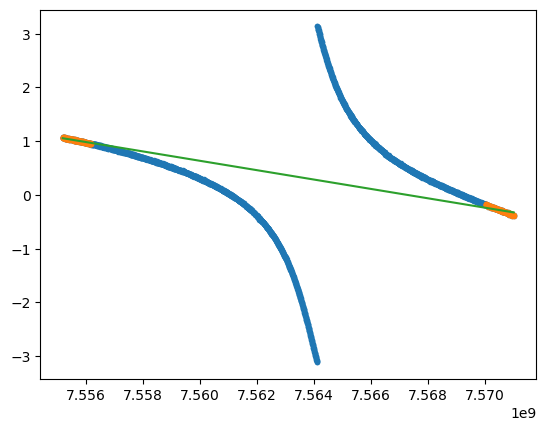

In [112]:
fig1, ax1 = plt.subplots(1)
fig2, ax2 = plt.subplots(1)

ax1.plot(data_freq, 20*np.log10(data_mag),'.')
ax1.plot(data_freq_400, 20*np.log10(data_mag_400),'.')

ax2.plot(data_freq, data_phase,'.')
ax2.plot(data_freq_400, data_phase_400,'.')

def linear_fit(f, m, b):
    return m*f+b

popts_mag = curve_fit(linear_fit, data_freq_400, data_mag_400)
popts_phase = curve_fit(linear_fit, data_freq_400, data_phase_400)

mag_fit_resp = linear_fit(data_freq, popts_mag[0][0], popts_mag[0][1])
ax1.plot(data_freq, 20*np.log10(mag_fit_resp))

phase_fit_resp = linear_fit(data_freq, popts_phase[0][0], popts_phase[0][1])
ax2.plot(data_freq, phase_fit_resp)

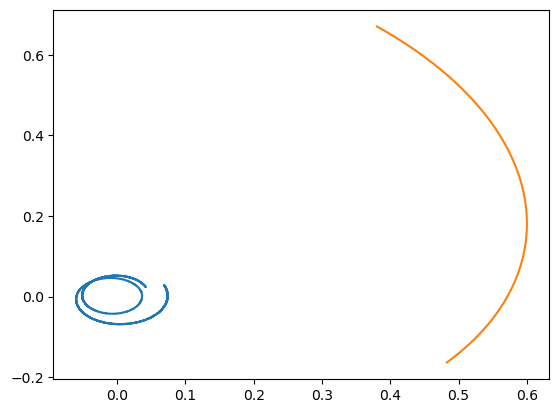

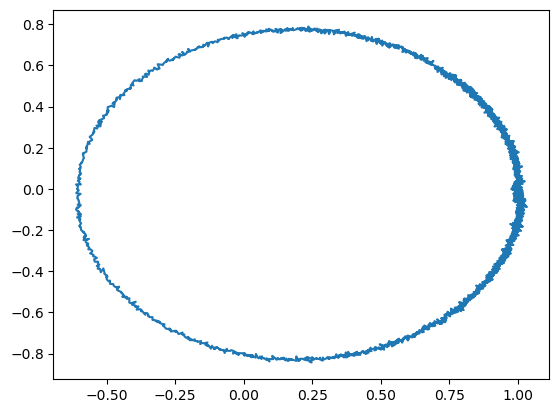

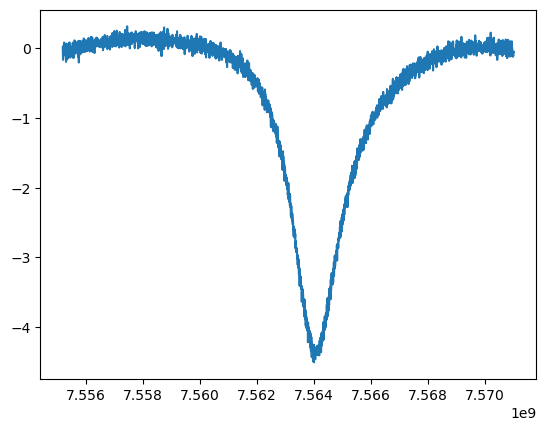

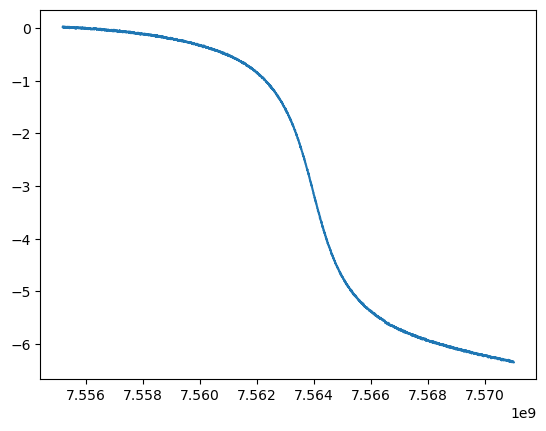

In [113]:
complex_linear = mag_fit_resp * np.exp(1j*phase_fit_resp)

fig3, ax3 = plt.subplots(1)

ax3.plot(np.real(data_resp), np.imag(data_resp))
ax3.plot(np.real(complex_linear),np.imag(complex_linear))

cleaned_data = data_no_background_resp / complex_linear

fig4, ax4 = plt.subplots(1)

ax4.plot(np.real(cleaned_data), np.imag(cleaned_data))

fig5, ax5 = plt.subplots(1)

ax5.plot(data_freq, 20*np.log10(np.abs(cleaned_data)))

fig6, ax6 = plt.subplots(1)

ax6.plot(data_freq, np.unwrap(np.angle(cleaned_data)))



f0 = 7.5640337171612195 GHz
Q0 = 10626.096568420704
β = 2.3414650941383592
φ = 3.1307227260785533
x_c = -0.030957622364058093
y_c = 0.007890638432915131


<Figure size 640x480 with 0 Axes>

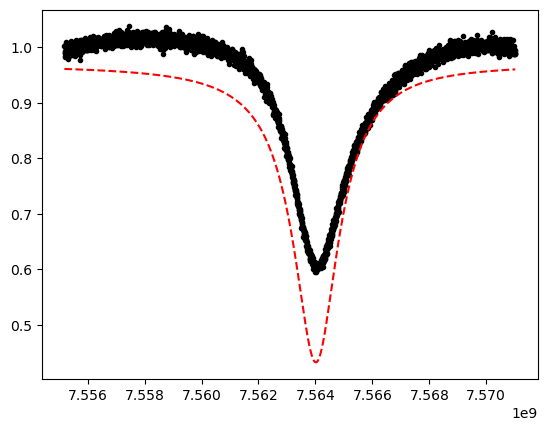

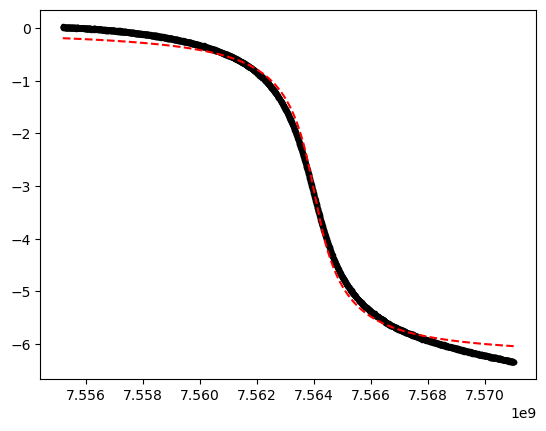

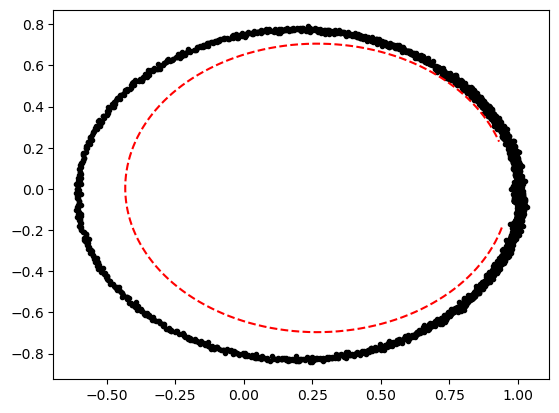

In [119]:
popt = resonator_fit(data_freq, cleaned_data, p0=[7.564e9, 7000, 1, np.pi, 0.25, 0], func=pp.linear_resonator_rotated_offset)
print(f'f0 = {popt[0]/1e9} GHz\nQ0 = {popt[1]}\nβ = {popt[2]}\nφ = {popt[3]}\nx_c = {popt[4]}\ny_c = {popt[5]}')   